# Лабораторная работа 4
#### Меркулов Роман Александрович
#### Группа 6


  





## Цель работы
Изучение методов экстраполяции данных, получение начальных навыков работы с библиотекой pandas и методы аппроксимации в библиотеке numpy.





## Ход работы

## 1.Подготовка к проекту
### 1.1 Импортируем необходимые библиотеки и загружаем данные

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.polynomial import Polynomial

df = pd.read_csv('Task_data_EURUSD.csv', sep=';')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   <TICKER>  25 non-null     str    
 1   <PER>     25 non-null     str    
 2   <DATE>    25 non-null     int64  
 3   <TIME>    25 non-null     int64  
 4   <OPEN>    24 non-null     str    
 5   <HIGH>    25 non-null     float64
 6   <LOW>     25 non-null     float64
 7   <CLOSE>   25 non-null     float64
dtypes: float64(3), int64(2), str(3)
memory usage: 1.7 KB


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>
0,EURUSD,D,210201,0,1.2122700,1.21365,1.2053,1.20677
1,EURUSD,D,210202,0,1.2067700,1.20878,1.2010,1.20360
2,EURUSD,D,210203,0,NaN,1.20502,1.2002,1.20410
3,EURUSD,D,210204,0,1.2041300,1.20430,1.1956,1.19656
4,EURUSD,D,210205,0,1.1966300,1.20500,1.1951,1.20476


### 1.2 Подготовка данных
Как мы видим, столбец OPEN содержит строковые значения, хотя по смыслу они числовые. Значит, нужно все это преобразовать к числовому типу, убрав NaN. Также при этом не допускаем сдвиг индексов

In [19]:
df['<OPEN>'] = pd.to_numeric(df['<OPEN>'], errors='coerce')
df = df.dropna(subset=['<OPEN>'])
df = df.reset_index(drop=True)
df['<OPEN>'] = df['<OPEN>'].astype('float64')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   <TICKER>  22 non-null     str    
 1   <PER>     22 non-null     str    
 2   <DATE>    22 non-null     int64  
 3   <TIME>    22 non-null     int64  
 4   <OPEN>    22 non-null     float64
 5   <HIGH>    22 non-null     float64
 6   <LOW>     22 non-null     float64
 7   <CLOSE>   22 non-null     float64
dtypes: float64(4), int64(2), str(2)
memory usage: 1.5 KB


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>
0,EURUSD,D,210201,0,1.21227,1.21365,1.20530,1.20677
1,EURUSD,D,210202,0,1.20677,1.20878,1.20100,1.20360
2,EURUSD,D,210204,0,1.20413,1.20430,1.19560,1.19656
3,EURUSD,D,210205,0,1.19663,1.20500,1.19510,1.20476
4,EURUSD,D,210207,0,1.20460,1.20551,1.20327,1.20484


Теперь данные готовы к дальнейшей работе над ними

## 2.Апроксимация данных
Выделенные части данных:
- train_days, train_prices — первые 15 дней (для обучения)
- all_days, all_prices — все 25 дней
- forecast_days, actual_forecast_prices — дни 16-25 (для проверки прогноза)

Соотвественно, строим полиномы 1, 2 и 7 степени по train, а также считаем ошибку методом наименьших квадратов на train, и на forecast


In [34]:
train_days = np.arange(1, 16, 1)
train_prices = df['<OPEN>'].to_numpy()[:15]

all_days = np.arange(1, df['<OPEN>'].size + 1)
all_prices = df['<OPEN>'].to_numpy()

forecast_days = all_days[14:]
actual_forecast_prices = all_prices[14:]

poly_1 = Polynomial.fit(train_days, train_prices, deg=1)
poly_2 = Polynomial.fit(train_days, train_prices, deg=2)
poly_7 = Polynomial.fit(train_days, train_prices, deg=7)

sse_train_1 = np.sum((train_prices - poly_1(train_days)) ** 2)
sse_train_2 = np.sum((train_prices - poly_2(train_days)) ** 2)
sse_train_7 = np.sum((train_prices - poly_7(train_days)) ** 2)

sse_forecast_1 = np.sum((actual_forecast_prices - poly_1(forecast_days)) ** 2)
sse_forecast_2 = np.sum((actual_forecast_prices - poly_2(forecast_days)) ** 2)
sse_forecast_7 = np.sum((actual_forecast_prices - poly_7(forecast_days)) ** 2)

## 3. Построение графика

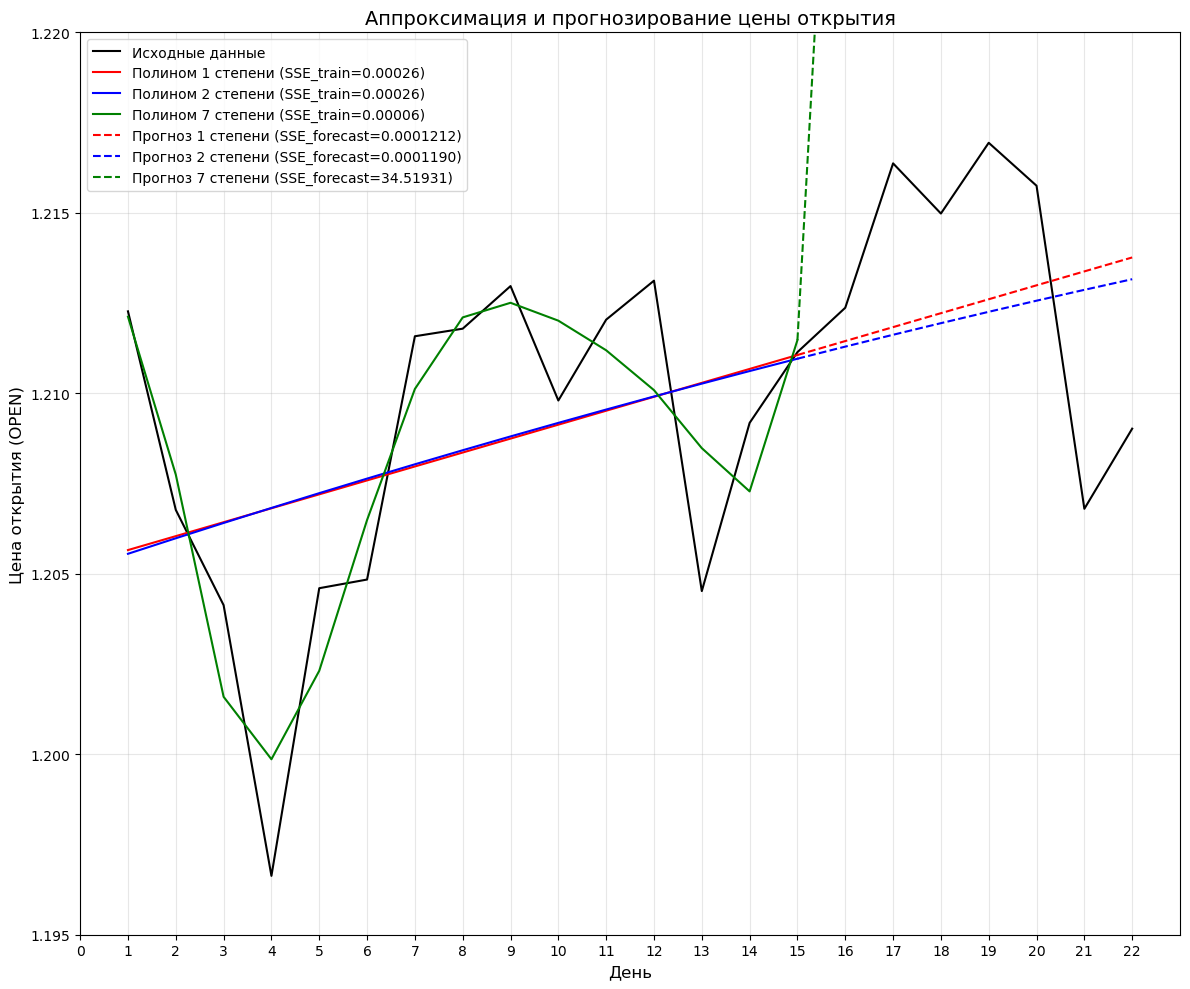

In [36]:
plt.figure(figsize=(12, 10))

plt.plot(all_days, all_prices, color='black', label='Исходные данные')
plt.plot(train_days, poly_1(train_days), color='red',label=f'Полином 1 степени (SSE_train={sse_train_1:.5f})')
plt.plot(train_days, poly_2(train_days), color='blue',label=f'Полином 2 степени (SSE_train={sse_train_2:.5f})')
plt.plot(train_days, poly_7(train_days), color='green', label=f'Полином 7 степени (SSE_train={sse_train_7:.5f})')

plt.plot(forecast_days, poly_1(forecast_days), '--', color='red', label=f'Прогноз 1 степени (SSE_forecast={sse_forecast_1:.7f})')
plt.plot(forecast_days, poly_2(forecast_days), '--', color='blue', label=f'Прогноз 2 степени (SSE_forecast={sse_forecast_2:.7f})')
plt.plot(forecast_days, poly_7(forecast_days), '--',  color='green', label=f'Прогноз 7 степени (SSE_forecast={sse_forecast_7:.5f})')

plt.xlim(0, 23)                
plt.ylim(1.195, 1.220)    
plt.xticks(np.arange(0, 23, 1))
plt.yticks(ticks=[1.195, 1.200, 1.205, 1.210, 1.215, 1.220])
plt.xlabel('День', fontsize=12)
plt.ylabel('Цена открытия (OPEN)', fontsize=12)
plt.title('Аппроксимация и прогнозирование цены открытия', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Вывод о точности моделей

Аппроксимация внутри интервала (дни 1-15):
Полином 7-й степени показывает наилучшую точность, так как он способен подстроиться под каждый нюанс данных, однако это свидетельствует о переобучении. Полиномы 1-й и 2-й степени имеют более высокую ошибку, но являются более обобщающими.

Прогнозирование за пределами интервала (дни 15-25):
Полином 1-й степени отличается от полинома 2-ой степени очень незначительно и оба дают наиболее точный прогноз, так как они улавливают только общий тренд и устойчивы к шуму. Полином 7-й степени показывает резкий рост ошибки при прогнозировании из-за переобучения на обучающих данных, что делает полиномы таких высоких степеней непригодными для предсказания будущих значений.